# Feature engineering

Build the daily modeling table for revenue forecasting.

## 2. Define target

Target column: `Revenue`.

In [22]:
from pathlib import Path

import numpy as np
import pandas as pd

pd.set_option("display.float_format", "{:,.2f}".format)

TARGET_COL = "Revenue"

data_dir_candidates = [Path("datathon"), Path("../datathon")]
DATA_DIR = next((path for path in data_dir_candidates if (path / "sales.csv").exists()), None)

if DATA_DIR is None:
    raise FileNotFoundError("Could not find datathon/sales.csv from the current working directory.")

SALES_PATH = DATA_DIR / "sales.csv"
SALES_PATH

WindowsPath('../datathon/sales.csv')

## 3. Create master daily table

Start from `sales.csv` and keep the daily grain with `Date` and `Revenue`.

In [2]:
sales = pd.read_csv(SALES_PATH, parse_dates=["Date"])

required_cols = ["Date", TARGET_COL]
missing_cols = sorted(set(required_cols) - set(sales.columns))
if missing_cols:
    raise ValueError(f"Missing required columns in sales.csv: {missing_cols}")

master_daily = (
    sales[required_cols]
    .copy()
    .groupby("Date", as_index=False)[TARGET_COL]
    .sum()
    .sort_values("Date")
    .reset_index(drop=True)
)

y = master_daily[TARGET_COL]

master_daily.head()

,Date,Revenue
0,2012-07-04,"5,123,547.94"
1,2012-07-05,"2,751,773.45"
2,2012-07-06,"3,054,029.42"
3,2012-07-07,"2,667,930.94"
4,2012-07-08,"2,360,851.90"


In [3]:
date_min = master_daily["Date"].min()
date_max = master_daily["Date"].max()
expected_dates = pd.date_range(date_min, date_max, freq="D")
missing_dates = expected_dates.difference(master_daily["Date"])

daily_table_check = {
    "rows": len(master_daily),
    "start_date": date_min,
    "end_date": date_max,
    "duplicate_dates": int(master_daily["Date"].duplicated().sum()),
    "missing_dates": len(missing_dates),
    "target_missing_values": int(master_daily[TARGET_COL].isna().sum()),
}

daily_table_check

{'rows': 3833,
 'start_date': Timestamp('2012-07-04 00:00:00'),
 'end_date': Timestamp('2022-12-31 00:00:00'),
 'duplicate_dates': 0,
 'missing_dates': 0,
 'target_missing_values': 0}

## 4. Aggregate supporting tables to daily grain

- `orders.csv` -> `order_count`
- `order_items.csv` + `orders.csv` -> `quantity_sold`, `discount_rate`
- `web_traffic.csv` -> `sessions`
- `promotions.csv` -> `active_promo_count`, `has_active_promo`

In [4]:
ORDERS_PATH = DATA_DIR / "orders.csv"
ORDER_ITEMS_PATH = DATA_DIR / "order_items.csv"
WEB_TRAFFIC_PATH = DATA_DIR / "web_traffic.csv"
PROMOTIONS_PATH = DATA_DIR / "promotions.csv"

for path in [ORDERS_PATH, ORDER_ITEMS_PATH, WEB_TRAFFIC_PATH, PROMOTIONS_PATH]:
    if not path.exists():
        raise FileNotFoundError(f"Missing required file: {path}")

### Orders and order items

In [5]:
orders = pd.read_csv(ORDERS_PATH, parse_dates=["order_date"])
order_items = pd.read_csv(
    ORDER_ITEMS_PATH,
    usecols=["order_id", "quantity", "unit_price", "discount_amount"],
)

order_count_daily = (
    orders.groupby("order_date")
    .size()
    .rename("order_count")
    .reset_index()
    .rename(columns={"order_date": "Date"})
)

order_items_with_date = order_items.merge(
    orders[["order_id", "order_date"]],
    on="order_id",
    how="left",
    validate="many_to_one",
)

missing_item_order_dates = int(order_items_with_date["order_date"].isna().sum())
if missing_item_order_dates:
    raise ValueError(f"Found {missing_item_order_dates:,} order item rows without order_date.")

order_items_with_date["gross_item_value"] = (
    order_items_with_date["quantity"] * order_items_with_date["unit_price"]
)

item_daily = (
    order_items_with_date.groupby("order_date", as_index=False)
    .agg(
        quantity_sold=("quantity", "sum"),
        gross_item_value=("gross_item_value", "sum"),
        discount_amount=("discount_amount", "sum"),
    )
    .rename(columns={"order_date": "Date"})
)

item_daily["discount_rate"] = (
    item_daily["discount_amount"]
    .div(item_daily["gross_item_value"])
    .where(item_daily["gross_item_value"].gt(0), 0)
)

item_daily = item_daily[["Date", "quantity_sold", "discount_rate"]]

order_count_daily.head(), item_daily.head()

(        Date  order_count
 0 2012-07-04          162
 1 2012-07-05           97
 2 2012-07-06           93
 3 2012-07-07           73
 4 2012-07-08           88,
         Date  quantity_sold  discount_rate
 0 2012-07-04            777           0.00
 1 2012-07-05            428           0.00
 2 2012-07-06            441           0.00
 3 2012-07-07            364           0.00
 4 2012-07-08            394           0.00)

### Web traffic

In [6]:
web_traffic = pd.read_csv(WEB_TRAFFIC_PATH, parse_dates=["date"])

traffic_daily = (
    web_traffic.groupby("date", as_index=False)["sessions"]
    .sum()
    .rename(columns={"date": "Date"})
)

traffic_daily.head()

,Date,sessions
0,2013-01-01,9760
1,2013-01-02,10456
2,2013-01-03,10076
3,2013-01-04,9973
4,2013-01-05,10223


### Promotions

In [7]:
promotions = pd.read_csv(PROMOTIONS_PATH, parse_dates=["start_date", "end_date"])
valid_promotions = promotions.dropna(subset=["start_date", "end_date"]).copy()

promo_daily = pd.DataFrame({"Date": master_daily["Date"]})
promo_daily["active_promo_count"] = 0

for promo in valid_promotions.itertuples(index=False):
    active_mask = promo_daily["Date"].between(promo.start_date, promo.end_date, inclusive="both")
    promo_daily.loc[active_mask, "active_promo_count"] += 1

promo_daily["has_active_promo"] = promo_daily["active_promo_count"].gt(0).astype(int)

promo_daily.head()

,Date,active_promo_count,has_active_promo
0,2012-07-04,0,0
1,2012-07-05,0,0
2,2012-07-06,0,0
3,2012-07-07,0,0
4,2012-07-08,0,0


### Merge daily aggregates into master table

In [8]:
daily_feature_tables = [
    order_count_daily,
    item_daily,
    traffic_daily,
    promo_daily,
]

for feature_table in daily_feature_tables:
    if feature_table["Date"].duplicated().any():
        duplicate_count = int(feature_table["Date"].duplicated().sum())
        raise ValueError(f"Feature table has {duplicate_count:,} duplicate Date rows.")

master_daily = master_daily.copy()
for feature_table in daily_feature_tables:
    master_daily = master_daily.merge(feature_table, on="Date", how="left")

zero_fill_cols = [
    "order_count",
    "quantity_sold",
    "discount_rate",
    "sessions",
    "active_promo_count",
    "has_active_promo",
]
master_daily[zero_fill_cols] = master_daily[zero_fill_cols].fillna(0)

int_cols = ["order_count", "quantity_sold", "sessions", "active_promo_count", "has_active_promo"]
master_daily[int_cols] = master_daily[int_cols].astype(int)

master_daily.head()

,Date,Revenue,order_count,quantity_sold,discount_rate,sessions,active_promo_count,has_active_promo
0,2012-07-04,"5,123,547.94",162,777,0.00,0,0,0
1,2012-07-05,"2,751,773.45",97,428,0.00,0,0,0
2,2012-07-06,"3,054,029.42",93,441,0.00,0,0,0
3,2012-07-07,"2,667,930.94",73,364,0.00,0,0,0
4,2012-07-08,"2,360,851.90",88,394,0.00,0,0,0


In [9]:
aggregate_check = {
    "rows": len(master_daily),
    "duplicate_dates": int(master_daily["Date"].duplicated().sum()),
    "missing_order_count": int(master_daily["order_count"].isna().sum()),
    "missing_quantity_sold": int(master_daily["quantity_sold"].isna().sum()),
    "missing_discount_rate": int(master_daily["discount_rate"].isna().sum()),
    "missing_sessions": int(master_daily["sessions"].isna().sum()),
    "missing_active_promo_count": int(master_daily["active_promo_count"].isna().sum()),
    "promo_days": int(master_daily["has_active_promo"].sum()),
}

aggregate_check

{'rows': 3833,
 'duplicate_dates': 0,
 'missing_order_count': 0,
 'missing_quantity_sold': 0,
 'missing_discount_rate': 0,
 'missing_sessions': 0,
 'missing_active_promo_count': 0,
 'promo_days': 1707}

## 5. Create calendar time features

These features are derived from `Date`, so they are available for both train and future prediction dates.

In [10]:
master_daily = master_daily.copy()

master_daily["year"] = master_daily["Date"].dt.year
master_daily["month"] = master_daily["Date"].dt.month
master_daily["quarter"] = master_daily["Date"].dt.quarter
master_daily["day_of_week"] = master_daily["Date"].dt.dayofweek
master_daily["is_weekend"] = master_daily["day_of_week"].isin([5, 6]).astype(int)
master_daily["day_of_month"] = master_daily["Date"].dt.day
master_daily["is_month_start_3d"] = master_daily["day_of_month"].le(3).astype(int)
master_daily["days_to_month_end"] = (
    master_daily["Date"].dt.days_in_month - master_daily["day_of_month"]
)
master_daily["is_month_end_4d"] = master_daily["days_to_month_end"].le(3).astype(int)

time_feature_cols = [
    "Date",
    "year",
    "month",
    "quarter",
    "day_of_week",
    "is_weekend",
    "day_of_month",
    "is_month_start_3d",
    "is_month_end_4d",
    "days_to_month_end",
]

master_daily[time_feature_cols].head()

,Date,year,month,quarter,day_of_week,is_weekend,day_of_month,is_month_start_3d,is_month_end_4d,days_to_month_end
0,2012-07-04,2012,7,3,2,0,4,0,0,27
1,2012-07-05,2012,7,3,3,0,5,0,0,26
2,2012-07-06,2012,7,3,4,0,6,0,0,25
3,2012-07-07,2012,7,3,5,1,7,0,0,24
4,2012-07-08,2012,7,3,6,1,8,0,0,23


In [11]:
time_feature_check = {
    "rows": len(master_daily),
    "missing_time_feature_values": int(master_daily[time_feature_cols].isna().sum().sum()),
    "weekend_days": int(master_daily["is_weekend"].sum()),
    "month_start_3d_days": int(master_daily["is_month_start_3d"].sum()),
    "month_end_4d_days": int(master_daily["is_month_end_4d"].sum()),
    "min_days_to_month_end": int(master_daily["days_to_month_end"].min()),
    "max_days_to_month_end": int(master_daily["days_to_month_end"].max()),
}

time_feature_check

{'rows': 3833,
 'missing_time_feature_values': 0,
 'weekend_days': 1095,
 'month_start_3d_days': 375,
 'month_end_4d_days': 504,
 'min_days_to_month_end': 0,
 'max_days_to_month_end': 30}

## 6. Create revenue lag and rolling features

Rolling features use `shift(1)` before the rolling window so the current day's revenue is never used to predict itself.

In [12]:
master_daily = master_daily.sort_values("Date").reset_index(drop=True).copy()

revenue_lags = [1, 7, 14, 28, 365]
for lag in revenue_lags:
    master_daily[f"revenue_lag_{lag}"] = master_daily[TARGET_COL].shift(lag)

revenue_history = master_daily[TARGET_COL].shift(1)

master_daily["revenue_roll_mean_7"] = revenue_history.rolling(window=7, min_periods=7).mean()
master_daily["revenue_roll_mean_28"] = revenue_history.rolling(window=28, min_periods=28).mean()
master_daily["revenue_roll_mean_90"] = revenue_history.rolling(window=90, min_periods=90).mean()
master_daily["revenue_roll_std_7"] = revenue_history.rolling(window=7, min_periods=7).std()
master_daily["revenue_roll_std_28"] = revenue_history.rolling(window=28, min_periods=28).std()
master_daily["revenue_roll_max_28"] = revenue_history.rolling(window=28, min_periods=28).max()
master_daily["revenue_roll_min_28"] = revenue_history.rolling(window=28, min_periods=28).min()

revenue_lag_roll_cols = [
    "Date",
    TARGET_COL,
    "revenue_lag_1",
    "revenue_lag_7",
    "revenue_lag_14",
    "revenue_lag_28",
    "revenue_lag_365",
    "revenue_roll_mean_7",
    "revenue_roll_mean_28",
    "revenue_roll_mean_90",
    "revenue_roll_std_7",
    "revenue_roll_std_28",
    "revenue_roll_max_28",
    "revenue_roll_min_28",
]

master_daily[revenue_lag_roll_cols].iloc[360:370]

,Date,Revenue,revenue_lag_1,revenue_lag_7,revenue_lag_14,revenue_lag_28,revenue_lag_365,revenue_roll_mean_7,revenue_roll_mean_28,revenue_roll_mean_90,revenue_roll_std_7,revenue_roll_std_28,revenue_roll_max_28,revenue_roll_min_28
360,2013-06-29,"9,546,012.78","6,285,354.21","5,117,274.96","5,166,292.57","13,162,597.88",NaN,"6,540,762.04","6,485,689.18","6,560,904.03","1,349,952.91","2,224,129.59","13,162,597.88","3,646,959.35"
361,2013-06-30,"7,372,318.59","9,546,012.78","5,844,565.63","5,794,009.15","12,079,925.72",NaN,"7,173,438.87","6,356,525.43","6,561,915.02","1,588,368.86","1,903,988.55","12,079,925.72","3,646,959.35"
362,2013-07-01,"6,359,864.53","7,372,318.59","5,243,774.50","5,795,298.96","9,411,997.25",NaN,"7,391,689.29","6,188,396.60","6,529,231.35","1,476,353.06","1,555,905.07","9,546,012.78","3,646,959.35"
363,2013-07-02,"7,209,130.33","6,359,864.53","6,728,887.10","6,632,615.61","5,397,308.75",NaN,"7,551,130.73","6,079,391.87","6,508,229.70","1,248,391.20","1,422,931.23","9,546,012.78","3,646,959.35"
364,2013-07-03,"8,038,680.63","7,209,130.33","8,817,278.13","7,437,341.02","6,860,958.96",NaN,"7,619,736.90","6,144,099.78","6,491,211.71","1,208,222.91","1,431,932.53","9,546,012.78","3,646,959.35"
365,2013-07-04,"2,521,315.44","8,038,680.63","7,748,199.74","7,078,652.68","5,692,902.11","5,123,547.94","7,508,508.69","6,186,161.27","6,533,078.60","1,111,577.14","1,470,545.93","9,546,012.78","3,646,959.35"
366,2013-07-05,"2,494,107.65","2,521,315.44","6,285,354.21","5,526,354.45","3,843,507.28","2,751,773.45","6,761,810.93","6,072,890.31","6,526,940.81","2,172,761.85","1,624,080.20","9,546,012.78","2,521,315.44"
367,2013-07-06,"2,452,372.43","2,494,107.65","9,546,012.78","5,117,274.96","3,646,959.35","3,054,029.42","6,220,204.28","6,024,697.47","6,513,950.93","2,715,949.20","1,710,411.37","9,546,012.78","2,494,107.65"
368,2013-07-07,"2,958,215.01","2,452,372.43","7,372,318.59","5,844,565.63","3,880,132.51","2,667,930.94","5,206,827.09","5,982,033.65","6,508,702.47","2,588,606.50","1,785,181.73","9,546,012.78","2,452,372.43"
369,2013-07-08,"2,571,901.18","2,958,215.01","6,359,864.53","5,243,774.50","4,476,887.83","2,360,851.90","4,576,240.86","5,949,108.03","6,489,672.92","2,509,605.93","1,833,239.68","9,546,012.78","2,452,372.43"


## 7. Create lag features for external variables

External same-day values such as sessions, orders, and quantity sold are not used directly for same-day revenue prediction. We keep lagged and historical rolling versions.

In [13]:
master_daily["sessions_lag_1"] = master_daily["sessions"].shift(1)
master_daily["sessions_roll_mean_7"] = master_daily["sessions"].shift(1).rolling(window=7, min_periods=7).mean()

master_daily["order_count_lag_1"] = master_daily["order_count"].shift(1)
master_daily["order_count_roll_mean_7"] = master_daily["order_count"].shift(1).rolling(window=7, min_periods=7).mean()

master_daily["quantity_sold_lag_1"] = master_daily["quantity_sold"].shift(1)
master_daily["quantity_sold_roll_mean_7"] = master_daily["quantity_sold"].shift(1).rolling(window=7, min_periods=7).mean()

master_daily["discount_rate_lag_7"] = master_daily["discount_rate"].shift(7)

external_lag_cols = [
    "Date",
    "sessions_lag_1",
    "sessions_roll_mean_7",
    "order_count_lag_1",
    "order_count_roll_mean_7",
    "quantity_sold_lag_1",
    "quantity_sold_roll_mean_7",
    "discount_rate_lag_7",
]

master_daily[external_lag_cols].head(10)

,Date,sessions_lag_1,sessions_roll_mean_7,order_count_lag_1,order_count_roll_mean_7,quantity_sold_lag_1,quantity_sold_roll_mean_7,discount_rate_lag_7
0,2012-07-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2012-07-05,0.00,NaN,162.00,NaN,777.00,NaN,NaN
2,2012-07-06,0.00,NaN,97.00,NaN,428.00,NaN,NaN
3,2012-07-07,0.00,NaN,93.00,NaN,441.00,NaN,NaN
4,2012-07-08,0.00,NaN,73.00,NaN,364.00,NaN,NaN
5,2012-07-09,0.00,NaN,88.00,NaN,394.00,NaN,NaN
6,2012-07-10,0.00,NaN,137.00,NaN,730.00,NaN,NaN
7,2012-07-11,0.00,0.00,183.00,119.00,928.00,580.29,0.00
8,2012-07-12,0.00,0.00,221.00,127.43,"1,097.00",626.00,0.00
9,2012-07-13,0.00,0.00,246.00,148.71,"1,241.00",742.14,0.00


In [14]:
lag_feature_cols = revenue_lag_roll_cols[2:] + external_lag_cols[1:]

lag_feature_check = {
    "rows": len(master_daily),
    "duplicate_dates": int(master_daily["Date"].duplicated().sum()),
    "created_lag_features": len(lag_feature_cols),
    "first_valid_revenue_lag_365_date": master_daily.loc[
        master_daily["revenue_lag_365"].notna(), "Date"
    ].min(),
    "first_valid_revenue_roll_mean_90_date": master_daily.loc[
        master_daily["revenue_roll_mean_90"].notna(), "Date"
    ].min(),
    "missing_values_by_feature": master_daily[lag_feature_cols].isna().sum().to_dict(),
}

lag_feature_check

{'rows': 3833,
 'duplicate_dates': 0,
 'created_lag_features': 19,
 'first_valid_revenue_lag_365_date': Timestamp('2013-07-04 00:00:00'),
 'first_valid_revenue_roll_mean_90_date': Timestamp('2012-10-02 00:00:00'),
 'missing_values_by_feature': {'revenue_lag_1': 1,
  'revenue_lag_7': 7,
  'revenue_lag_14': 14,
  'revenue_lag_28': 28,
  'revenue_lag_365': 365,
  'revenue_roll_mean_7': 7,
  'revenue_roll_mean_28': 28,
  'revenue_roll_mean_90': 90,
  'revenue_roll_std_7': 7,
  'revenue_roll_std_28': 28,
  'revenue_roll_max_28': 28,
  'revenue_roll_min_28': 28,
  'sessions_lag_1': 1,
  'sessions_roll_mean_7': 7,
  'order_count_lag_1': 1,
  'order_count_roll_mean_7': 7,
  'quantity_sold_lag_1': 1,
  'quantity_sold_roll_mean_7': 7,
  'discount_rate_lag_7': 7}}

## 8. Handle missing values

Missing values are expected at the beginning of the time series because lag and rolling features need historical data. Keep `master_daily` unchanged for auditing, and create `model_df` by dropping rows that do not have enough lag history.

In [15]:
missing_before_drop = master_daily.isna().sum()
missing_before_drop = missing_before_drop[missing_before_drop.gt(0)].sort_values(ascending=False)

missing_before_drop

revenue_lag_365              365
revenue_roll_mean_90          90
revenue_roll_mean_28          28
revenue_roll_max_28           28
revenue_roll_std_28           28
revenue_roll_min_28           28
revenue_lag_28                28
revenue_lag_14                14
revenue_lag_7                  7
revenue_roll_std_7             7
revenue_roll_mean_7            7
discount_rate_lag_7            7
sessions_roll_mean_7           7
quantity_sold_roll_mean_7      7
order_count_roll_mean_7        7
revenue_lag_1                  1
sessions_lag_1                 1
order_count_lag_1              1
quantity_sold_lag_1            1
dtype: int64

In [16]:
model_df = master_daily.dropna(subset=lag_feature_cols).reset_index(drop=True)

missing_after_drop = model_df.isna().sum()
missing_after_drop = missing_after_drop[missing_after_drop.gt(0)].sort_values(ascending=False)

missing_value_check = {
    "master_daily_rows": len(master_daily),
    "model_df_rows": len(model_df),
    "dropped_rows": len(master_daily) - len(model_df),
    "model_start_date": model_df["Date"].min(),
    "model_end_date": model_df["Date"].max(),
    "remaining_missing_values": int(model_df.isna().sum().sum()),
}

missing_value_check

{'master_daily_rows': 3833,
 'model_df_rows': 3468,
 'dropped_rows': 365,
 'model_start_date': Timestamp('2013-07-04 00:00:00'),
 'model_end_date': Timestamp('2022-12-31 00:00:00'),
 'remaining_missing_values': 0}

## 9. Split train, validation, and test by time

Use only data before 2019 because the later period may contain abnormal events. After dropping rows without enough lag history, the modeling data starts on `2013-07-04`. That leaves less than six full years before 2019, so this split uses three years for train, one year for validation, and all remaining pre-2019 data for test.

- Train: `2013-07-04` to `2016-07-03`
- Validation: `2016-07-04` to `2017-07-03`
- Test: `2017-07-04` to `2018-12-31`

In [19]:
analysis_start_date = model_df["Date"].min()
train_start_date = analysis_start_date
train_end_date = train_start_date + pd.DateOffset(years=3)
valid_start_date = train_end_date
valid_end_date = valid_start_date + pd.DateOffset(years=1)
test_start_date = valid_end_date
test_end_date = pd.Timestamp("2019-01-01")

model_df_pre2019 = model_df[
    (model_df["Date"] >= analysis_start_date)
    & (model_df["Date"] < test_end_date)
].copy()

train_df = model_df_pre2019[
    (model_df_pre2019["Date"] >= train_start_date)
    & (model_df_pre2019["Date"] < train_end_date)
].copy()
valid_df = model_df_pre2019[
    (model_df_pre2019["Date"] >= valid_start_date)
    & (model_df_pre2019["Date"] < valid_end_date)
].copy()
test_df = model_df_pre2019[
    (model_df_pre2019["Date"] >= test_start_date)
    & (model_df_pre2019["Date"] < test_end_date)
].copy()

split_summary = pd.DataFrame(
    [
        {
            "split": "train",
            "rows": len(train_df),
            "start_date": train_df["Date"].min(),
            "end_date": train_df["Date"].max(),
        },
        {
            "split": "valid",
            "rows": len(valid_df),
            "start_date": valid_df["Date"].min(),
            "end_date": valid_df["Date"].max(),
        },
        {
            "split": "test",
            "rows": len(test_df),
            "start_date": test_df["Date"].min(),
            "end_date": test_df["Date"].max(),
        },
    ]
)

split_summary

,split,rows,start_date,end_date
0,train,1096,2013-07-04,2016-07-03
1,valid,365,2016-07-04,2017-07-03
2,test,546,2017-07-04,2018-12-31


In [20]:
split_rows = len(train_df) + len(valid_df) + len(test_df)
train_days = (train_df["Date"].max() - train_df["Date"].min()).days + 1
valid_days = (valid_df["Date"].max() - valid_df["Date"].min()).days + 1
test_days = (test_df["Date"].max() - test_df["Date"].min()).days + 1

split_check = {
    "model_df_pre2019_rows": len(model_df_pre2019),
    "split_rows": split_rows,
    "unused_rows_before_2019": len(model_df_pre2019) - split_rows,
    "train_days": train_days,
    "valid_days": valid_days,
    "test_days": test_days,
    "train_max_before_valid_start": bool(train_df["Date"].max() < valid_start_date),
    "valid_range_ok": bool(
        (valid_df["Date"].min() >= valid_start_date)
        and (valid_df["Date"].max() < valid_end_date)
    ),
    "test_range_ok": bool(
        (test_df["Date"].min() >= test_start_date)
        and (test_df["Date"].max() < test_end_date)
    ),
    "remaining_missing_values": int(
        train_df.isna().sum().sum()
        + valid_df.isna().sum().sum()
        + test_df.isna().sum().sum()
    ),
}

split_check

{'model_df_pre2019_rows': 2007,
 'split_rows': 2007,
 'unused_rows_before_2019': 0,
 'train_days': 1096,
 'valid_days': 365,
 'test_days': 546,
 'train_max_before_valid_start': True,
 'valid_range_ok': True,
 'test_range_ok': True,
 'remaining_missing_values': 0}

## 10. Audit data types, distributions, and prepare model matrices

Before modeling, check column types and distributions, convert binary flags to numeric `0/1`, detect categorical columns, and define the final feature set. Same-day operational columns such as `sessions`, `order_count`, `quantity_sold`, and `discount_rate` are excluded to avoid using information that may not be known at prediction time.

In [23]:
for split_df in [model_df_pre2019, train_df, valid_df, test_df]:
    split_df["log_revenue"] = np.log1p(split_df[TARGET_COL])

raw_same_day_cols = ["order_count", "quantity_sold", "discount_rate", "sessions"]
target_cols = [TARGET_COL, "log_revenue"]
id_cols = ["Date"]

selected_feature_cols = [
    "year",
    "month",
    "quarter",
    "day_of_week",
    "is_weekend",
    "day_of_month",
    "is_month_start_3d",
    "is_month_end_4d",
    "days_to_month_end",
    "active_promo_count",
    "has_active_promo",
] + lag_feature_cols

missing_selected_features = sorted(set(selected_feature_cols) - set(train_df.columns))
if missing_selected_features:
    raise ValueError(f"Missing selected features: {missing_selected_features}")

leakage_cols_in_features = sorted(set(raw_same_day_cols + target_cols + id_cols) & set(selected_feature_cols))
if leakage_cols_in_features:
    raise ValueError(f"Leakage columns found in selected features: {leakage_cols_in_features}")

binary_cols = [
    "is_weekend",
    "is_month_start_3d",
    "is_month_end_4d",
    "has_active_promo",
]

for split_df in [model_df_pre2019, train_df, valid_df, test_df]:
    split_df[binary_cols] = split_df[binary_cols].astype(int)

X_train_raw = train_df[selected_feature_cols].copy()
X_valid_raw = valid_df[selected_feature_cols].copy()
X_test_raw = test_df[selected_feature_cols].copy()

y_train = train_df["log_revenue"].copy()
y_valid = valid_df["log_revenue"].copy()
y_test = test_df["log_revenue"].copy()

X_train_raw.head()

,year,month,quarter,day_of_week,is_weekend,day_of_month,is_month_start_3d,is_month_end_4d,days_to_month_end,active_promo_count,...,revenue_roll_std_28,revenue_roll_max_28,revenue_roll_min_28,sessions_lag_1,sessions_roll_mean_7,order_count_lag_1,order_count_roll_mean_7,quantity_sold_lag_1,quantity_sold_roll_mean_7,discount_rate_lag_7
0,2013,7,3,3,0,4,0,0,27,1,...,"1,470,545.93","9,546,012.78","3,646,959.35","20,624.00","24,241.43",369.00,374.86,"1,866.00","1,881.14",0.18
1,2013,7,3,4,0,5,0,0,26,1,...,"1,624,080.20","9,546,012.78","2,521,315.44","20,224.00","23,338.43",93.00,334.71,483.00,"1,687.57",0.18
2,2013,7,3,5,1,6,0,0,25,1,...,"1,710,411.37","9,546,012.78","2,494,107.65","22,308.00","23,112.29",108.00,303.29,553.00,"1,536.71",0.18
3,2013,7,3,6,1,7,0,0,24,1,...,"1,785,181.73","9,546,012.78","2,452,372.43","19,852.00","21,813.00",94.00,246.14,499.00,"1,246.71",0.18
4,2013,7,3,0,0,8,0,0,23,1,...,"1,833,239.68","9,546,012.78","2,452,372.43","19,573.00","20,779.43",116.00,207.00,568.00,"1,044.29",0.18


In [25]:
dtype_summary = (
    train_df[id_cols + target_cols + selected_feature_cols]
    .dtypes
    .astype(str)
    .rename("dtype")
    .reset_index()
    .rename(columns={"index": "column"})
)

numeric_feature_cols = X_train_raw.select_dtypes(include=["number", "bool"]).columns.tolist()
categorical_feature_cols = X_train_raw.select_dtypes(exclude=["number", "bool"]).columns.tolist()

preprocess_schema = {
    "selected_features": len(selected_feature_cols),
    "numeric_features": len(numeric_feature_cols),
    "categorical_features": len(categorical_feature_cols),
    "binary_features": binary_cols,
    "raw_same_day_columns_excluded": raw_same_day_cols,
}

preprocess_schema

{'selected_features': 30,
 'numeric_features': 30,
 'categorical_features': 0,
 'binary_features': ['is_weekend',
  'is_month_start_3d',
  'is_month_end_4d',
  'has_active_promo'],
 'raw_same_day_columns_excluded': ['order_count',
  'quantity_sold',
  'discount_rate',
  'sessions']}

In [26]:
distribution_summary = X_train_raw.describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]).T
distribution_summary["skew"] = X_train_raw.skew(numeric_only=True)
distribution_summary["missing"] = X_train_raw.isna().sum()
distribution_summary["n_unique"] = X_train_raw.nunique()

distribution_summary.sort_values("skew", key=lambda s: s.abs(), ascending=False).head(15)

,count,mean,std,min,1%,5%,50%,95%,99%,max,skew,missing,n_unique
is_month_start_3d,"1,096.00",0.10,0.30,0.00,0.00,0.00,0.00,1.00,1.00,1.00,2.70,0,2
is_month_end_4d,"1,096.00",0.13,0.34,0.00,0.00,0.00,0.00,1.00,1.00,1.00,2.19,0,2
revenue_roll_std_7,"1,096.00","1,362,672.87","965,163.05","186,180.21","349,662.05","453,543.87","1,047,591.77","3,675,154.26","4,465,430.81","5,643,616.88",1.74,0,1096
revenue_lag_28,"1,096.00","5,141,590.62","2,739,534.93","709,982.79","1,618,105.89","2,092,557.80","4,549,724.85","10,957,855.63","14,818,528.03","17,388,183.19",1.50,0,1096
revenue_lag_14,"1,096.00","5,165,091.50","2,752,300.87","709,982.79","1,618,105.89","2,092,557.80","4,573,939.63","10,957,855.63","14,818,528.03","17,388,183.19",1.47,0,1096
revenue_lag_365,"1,096.00","4,920,821.97","2,553,027.39","279,813.94","1,625,213.53","2,125,944.87","4,315,361.68","10,123,353.42","13,703,453.34","17,347,427.27",1.46,0,1096
revenue_lag_7,"1,096.00","5,176,982.87","2,761,641.28","709,982.79","1,618,105.89","2,092,557.80","4,573,939.63","10,957,855.63","14,818,528.03","17,388,183.19",1.45,0,1096
revenue_lag_1,"1,096.00","5,190,432.51","2,782,036.62","709,982.79","1,618,105.89","2,092,557.80","4,573,939.63","11,015,675.80","14,818,528.03","17,388,183.19",1.45,0,1096
quantity_sold_lag_1,"1,096.00","1,132.14",597.99,105.00,332.70,453.00,998.00,"2,477.50","3,063.30","3,503.00",1.42,0,801
order_count_lag_1,"1,096.00",224.20,117.43,26.00,66.85,90.00,198.00,475.00,604.45,700.00,1.38,0,384


In [27]:
target_distribution_summary = train_df[[TARGET_COL, "log_revenue"]].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]).T
target_distribution_summary["skew"] = train_df[[TARGET_COL, "log_revenue"]].skew(numeric_only=True)

target_distribution_summary

,count,mean,std,min,1%,5%,50%,95%,99%,max,skew
Revenue,"1,096.00","5,188,961.70","2,780,955.34","709,982.79","1,618,105.89","2,092,557.80","4,573,939.63","11,015,675.80","14,818,528.03","17,388,183.19",1.45
log_revenue,"1,096.00",15.33,0.50,13.47,14.30,14.55,15.34,16.21,16.51,16.67,0.10


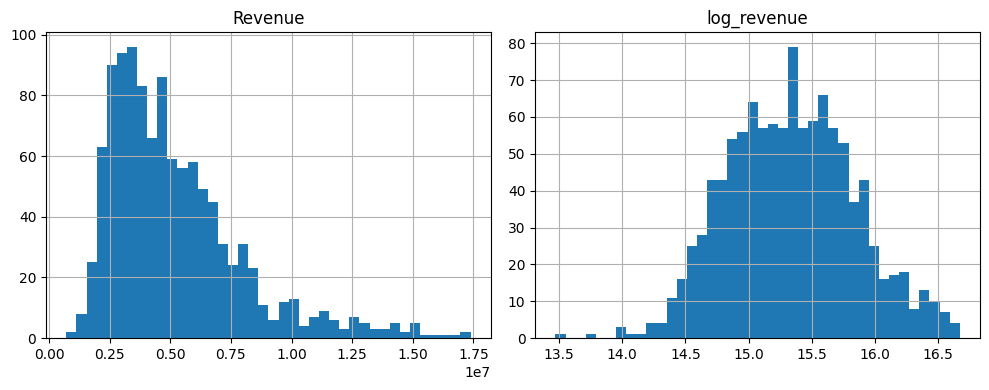

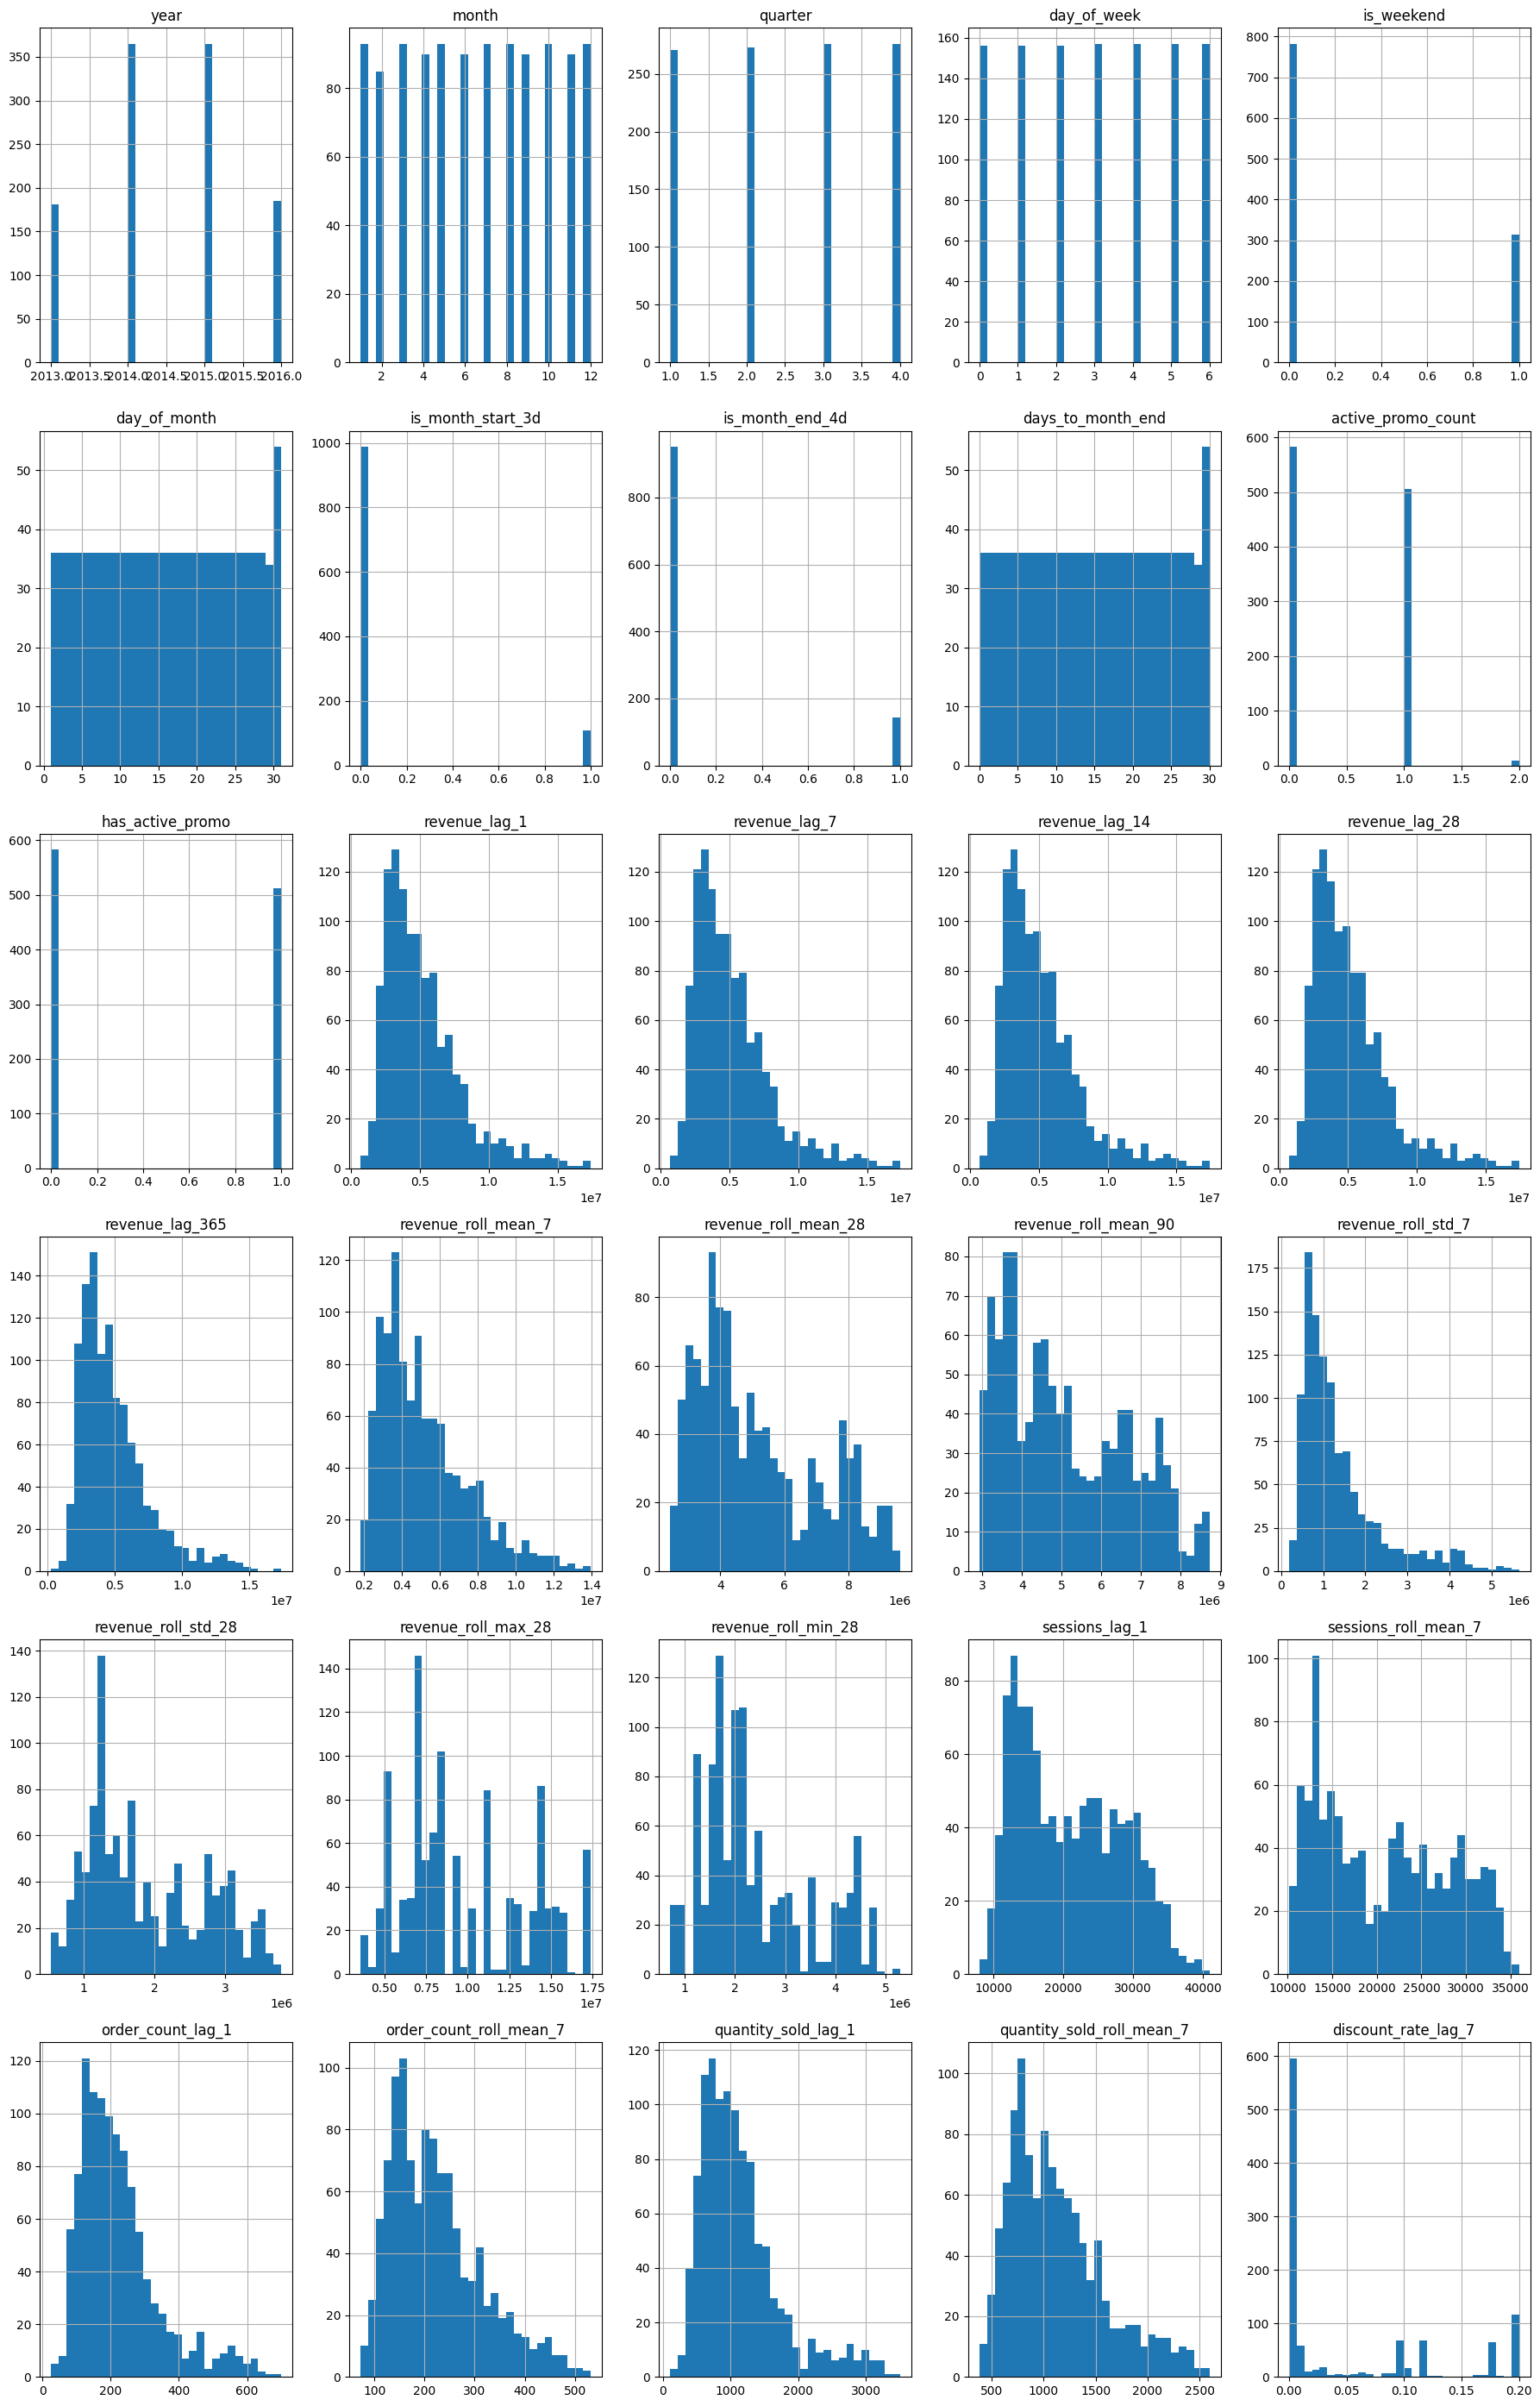

In [28]:
import matplotlib.pyplot as plt

train_df[[TARGET_COL, "log_revenue"]].hist(bins=40, figsize=(10, 4))
plt.tight_layout()
plt.show()

X_train_raw[selected_feature_cols].hist(bins=30, figsize=(18, 28))
plt.tight_layout()
plt.show()

In [29]:
def encode_feature_frame(df, categorical_cols):
    if not categorical_cols:
        return df.copy()
    return pd.get_dummies(df, columns=categorical_cols, drop_first=False, dtype=int)


X_train = encode_feature_frame(X_train_raw, categorical_feature_cols)
X_valid = encode_feature_frame(X_valid_raw, categorical_feature_cols).reindex(columns=X_train.columns, fill_value=0)
X_test = encode_feature_frame(X_test_raw, categorical_feature_cols).reindex(columns=X_train.columns, fill_value=0)

preprocess_check = {
    "X_train_shape": X_train.shape,
    "X_valid_shape": X_valid.shape,
    "X_test_shape": X_test.shape,
    "y_train_length": len(y_train),
    "y_valid_length": len(y_valid),
    "y_test_length": len(y_test),
    "remaining_missing_values": int(
        X_train.isna().sum().sum()
        + X_valid.isna().sum().sum()
        + X_test.isna().sum().sum()
    ),
    "all_features_numeric": bool(all(pd.api.types.is_numeric_dtype(X_train[col]) for col in X_train.columns)),
}

preprocess_check

{'X_train_shape': (1096, 30),
 'X_valid_shape': (365, 30),
 'X_test_shape': (546, 30),
 'y_train_length': 1096,
 'y_valid_length': 365,
 'y_test_length': 546,
 'remaining_missing_values': 0,
 'all_features_numeric': True}

### Train data sample

In [32]:
sample_cols = [
    "Date",
    TARGET_COL,
    "log_revenue",
    "year",
    "month",
    "day_of_week",
    "is_weekend",
    "active_promo_count",
    "has_active_promo",
    "revenue_lag_1",
    "revenue_lag_7",
    "revenue_roll_mean_7",
    "sessions_lag_1",
    "order_count_lag_1",
    "quantity_sold_lag_1",
    "discount_rate_lag_7",
]

train_df[sample_cols].head(20)

,Date,Revenue,log_revenue,year,month,day_of_week,is_weekend,active_promo_count,has_active_promo,revenue_lag_1,revenue_lag_7,revenue_roll_mean_7,sessions_lag_1,order_count_lag_1,quantity_sold_lag_1,discount_rate_lag_7
0,2013-07-04,"2,521,315.44",14.74,2013,7,3,0,1,1,"8,038,680.63","7,748,199.74","7,508,508.69","20,624.00",369.00,"1,866.00",0.18
1,2013-07-05,"2,494,107.65",14.73,2013,7,4,0,1,1,"2,521,315.44","6,285,354.21","6,761,810.93","20,224.00",93.00,483.00,0.18
2,2013-07-06,"2,452,372.43",14.71,2013,7,5,1,1,1,"2,494,107.65","9,546,012.78","6,220,204.28","22,308.00",108.00,553.00,0.18
3,2013-07-07,"2,958,215.01",14.90,2013,7,6,1,1,1,"2,452,372.43","7,372,318.59","5,206,827.09","19,852.00",94.00,499.00,0.18
4,2013-07-08,"2,571,901.18",14.76,2013,7,0,0,1,1,"2,958,215.01","6,359,864.53","4,576,240.86","19,573.00",116.00,568.00,0.18
5,2013-07-09,"4,624,825.33",15.35,2013,7,1,0,1,1,"2,571,901.18","7,209,130.33","4,035,103.24","18,865.00",115.00,603.00,0.18
6,2013-07-10,"3,855,254.64",15.16,2013,7,2,0,1,1,"4,624,825.33","8,038,680.63","3,665,916.81","22,779.00",204.00,"1,015.00",0.18
7,2013-07-11,"5,785,320.61",15.57,2013,7,3,0,1,1,"3,855,254.64","2,521,315.44","3,068,284.53","22,911.00",199.00,963.00,0.18
8,2013-07-12,"6,053,300.71",15.62,2013,7,4,0,1,1,"5,785,320.61","2,494,107.65","3,534,570.98","22,159.00",285.00,"1,402.00",0.18
9,2013-07-13,"4,161,301.31",15.24,2013,7,5,1,1,1,"6,053,300.71","2,452,372.43","4,043,027.13","21,395.00",272.00,"1,379.00",0.18


## 11. Save processed train, validation, and test datasets

In [33]:
import json

OUTPUT_DIR = Path("processed_features")
if not Path.cwd().name.startswith("task_29_05_2026"):
    OUTPUT_DIR = Path("task_29_05_2026") / OUTPUT_DIR

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

train_path = OUTPUT_DIR / "train_features.csv"
valid_path = OUTPUT_DIR / "valid_features.csv"
test_path = OUTPUT_DIR / "test_features.csv"
feature_columns_path = OUTPUT_DIR / "feature_columns.json"

train_df.to_csv(train_path, index=False)
valid_df.to_csv(valid_path, index=False)
test_df.to_csv(test_path, index=False)

feature_metadata = {
    "target_column": TARGET_COL,
    "model_target_column": "log_revenue",
    "feature_columns": selected_feature_cols,
    "binary_columns": binary_cols,
    "categorical_columns": categorical_feature_cols,
    "excluded_same_day_columns": raw_same_day_cols,
    "splits": {
        "train": {
            "rows": len(train_df),
            "start_date": str(train_df["Date"].min().date()),
            "end_date": str(train_df["Date"].max().date()),
        },
        "valid": {
            "rows": len(valid_df),
            "start_date": str(valid_df["Date"].min().date()),
            "end_date": str(valid_df["Date"].max().date()),
        },
        "test": {
            "rows": len(test_df),
            "start_date": str(test_df["Date"].min().date()),
            "end_date": str(test_df["Date"].max().date()),
        },
    },
}

with open(feature_columns_path, "w", encoding="utf-8") as f:
    json.dump(feature_metadata, f, indent=2, ensure_ascii=False)

saved_files = {
    "output_dir": str(OUTPUT_DIR),
    "train_features": str(train_path),
    "valid_features": str(valid_path),
    "test_features": str(test_path),
    "feature_columns": str(feature_columns_path),
}

saved_files

{'output_dir': 'processed_features',
 'train_features': 'processed_features\\train_features.csv',
 'valid_features': 'processed_features\\valid_features.csv',
 'test_features': 'processed_features\\test_features.csv',
 'feature_columns': 'processed_features\\feature_columns.json'}